# How to Train a RF-DETR Instance Segmentation Model with Custom Data

We will show you how to train a RF-DETR instance segmentation model with your images and annotations and export to a Core ML model which can be used for auto labeling on RectLabel.

### Use GPU

Let's make sure that we have access to GPU. We can use `nvidia-smi` command to do that. In case of any problems navigate to `Runtime` -> `Change runtime type` -> `Hardware accelerator`, set it to `GPU`, and then click `Save`.

In [1]:
!nvidia-smi

Fri Mar 27 22:35:54 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   33C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

### Install PyTorch 2.8.0

In [2]:
!pip install -q torch==2.8.0 torchvision torchaudio --index-url https://download.pytorch.org/whl/cu128


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 322.4/322.4 MB 45.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 889.0/889.0 MB 1.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 155.6/155.6 MB 7.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.6/8.6 MB 25.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 45.4 MB/s eta 0:00:00


### Install RF-DETR 1.5.1

In [3]:
!pip install -q rfdetr==1.5.1

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 4.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.9/41.9 kB 4.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 187.9/187.9 kB 9.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 274.9/274.9 kB 28.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.0/12.0 MB 85.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 95.8/95.8 kB 10.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 7.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 11.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 217.4/217.4 kB 18.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 37.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 62.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 103.6 MB/s eta 0:00:00


### Download training images and annotations

Download training images and annotations. You can use these or replace them with your own data.

In [4]:
!mkdir datasets
%cd datasets
!wget -q https://huggingface.co/datasets/rectlabel/datasets/resolve/main/donut_coco.zip
!unzip -q donut_coco.zip
%cd ..

/content/datasets
/content


### Fine-tune RF-DETR on custom dataset

Start training from the current content folder.

In [5]:
from rfdetr import RFDETRSegNano

model = RFDETRSegNano()
dataset_dir = "datasets/donut_coco"
model.train(dataset_dir=dataset_dir, epochs=20, batch_size=4, grad_accum_steps=4)

[2026-03-27 22:38:48] [INFO] rf-detr - Downloading pretrained weights for rf-detr-seg-nano.pt


rf-detr-seg-nano.pt:   0%|          | 0.00/128M [00:00<?, ?iB/s]

[2026-03-27 22:38:51] [INFO] rf-detr - MD5 validation successful for rf-detr-seg-nano.pt


[2026-03-27 22:38:51] [WARNING] rf-detr - Using a different number of positional encodings than DINOv2, which means we're not loading DINOv2 backbone weights. This is not a problem if finetuning a pretrained RF-DETR model.
[2026-03-27 22:38:51] [WARNING] rf-detr - Using patch size 12 instead of 14, which means we're not loading DINOv2 backbone weights. This is not a problem if finetuning a pretrained RF-DETR model.


[2026-03-27 22:38:52] [INFO] rf-detr - Loading pretrain weights


...

[2026-03-27 22:46:45] [INFO] rf-detr - Epoch: [16/20]  [0/5]  eta: 0:00:34  lr: 0.000100  class_error: 0.00  loss: 15.0886 (15.0886)  loss_ce: 1.2523 (1.2523)  loss_bbox: 0.1347 (0.1347)  loss_giou: 0.1316 (0.1316)  loss_mask_ce: 0.1897 (0.1897)  loss_mask_dice: 0.1928 (0.1928)  loss_ce_0: 3.9947 (3.9947)  loss_bbox_0: 0.1430 (0.1430)  loss_giou_0: 0.1352 (0.1352)  loss_mask_ce_0: 0.1359 (0.1359)  loss_mask_dice_0: 0.1412 (0.1412)  loss_ce_1: 2.3632 (2.3632)  loss_bbox_1: 0.1330 (0.1330)  loss_giou_1: 0.1182 (0.1182)  loss_mask_ce_1: 0.1498 (0.1498)  loss_mask_dice_1: 0.1192 (0.1192)  loss_ce_2: 1.3760 (1.3760)  loss_bbox_2: 0.1187 (0.1187)  loss_giou_2: 0.1018 (0.1018)  loss_mask_ce_2: 0.1619 (0.1619)  loss_mask_dice_2: 0.1194 (0.1194)  loss_ce_enc: 2.6468 (2.6468)  loss_bbox_enc: 0.3979 (0.3979)  loss_giou_enc: 0.3317 (0.3317)  loss_mask_ce_enc: 0.2267 (0.2267)  loss_mask_dice_enc: 0.2732 (0.2732)  loss_ce_unscaled: 0.2505 (0.2505)  class_error_unscaled: 0.0000 (0.0000)  loss_bbox_un

[2026-03-27 22:47:12] [INFO] rf-detr - Epoch: [17/20]  [0/5]  eta: 0:00:28  lr: 0.000100  class_error: 0.00  loss: 14.4228 (14.4228)  loss_ce: 1.1968 (1.1968)  loss_bbox: 0.0951 (0.0951)  loss_giou: 0.1080 (0.1080)  loss_mask_ce: 0.1201 (0.1201)  loss_mask_dice: 0.1190 (0.1190)  loss_ce_0: 4.0238 (4.0238)  loss_bbox_0: 0.1089 (0.1089)  loss_giou_0: 0.1261 (0.1261)  loss_mask_ce_0: 0.1298 (0.1298)  loss_mask_dice_0: 0.1550 (0.1550)  loss_ce_1: 2.3022 (2.3022)  loss_bbox_1: 0.1160 (0.1160)  loss_giou_1: 0.1397 (0.1397)  loss_mask_ce_1: 0.1245 (0.1245)  loss_mask_dice_1: 0.1336 (0.1336)  loss_ce_2: 1.5625 (1.5625)  loss_bbox_2: 0.1166 (0.1166)  loss_giou_2: 0.1191 (0.1191)  loss_mask_ce_2: 0.1214 (0.1214)  loss_mask_dice_2: 0.1185 (0.1185)  loss_ce_enc: 2.3693 (2.3693)  loss_bbox_enc: 0.2696 (0.2696)  loss_giou_enc: 0.2396 (0.2396)  loss_mask_ce_enc: 0.2308 (0.2308)  loss_mask_dice_enc: 0.2768 (0.2768)  loss_ce_unscaled: 0.2394 (0.2394)  class_error_unscaled: 0.0000 (0.0000)  loss_bbox_un

[2026-03-27 22:47:45] [INFO] rf-detr - Epoch: [18/20]  [0/5]  eta: 0:00:41  lr: 0.000100  class_error: -0.00  loss: 13.3591 (13.3591)  loss_ce: 1.0499 (1.0499)  loss_bbox: 0.0629 (0.0629)  loss_giou: 0.0839 (0.0839)  loss_mask_ce: 0.0967 (0.0967)  loss_mask_dice: 0.0915 (0.0915)  loss_ce_0: 3.9552 (3.9552)  loss_bbox_0: 0.0860 (0.0860)  loss_giou_0: 0.1129 (0.1129)  loss_mask_ce_0: 0.0929 (0.0929)  loss_mask_dice_0: 0.1132 (0.1132)  loss_ce_1: 2.0848 (2.0848)  loss_bbox_1: 0.0762 (0.0762)  loss_giou_1: 0.1012 (0.1012)  loss_mask_ce_1: 0.0966 (0.0966)  loss_mask_dice_1: 0.1046 (0.1046)  loss_ce_2: 1.3675 (1.3675)  loss_bbox_2: 0.0747 (0.0747)  loss_giou_2: 0.1037 (0.1037)  loss_mask_ce_2: 0.1011 (0.1011)  loss_mask_dice_2: 0.1031 (0.1031)  loss_ce_enc: 2.4355 (2.4355)  loss_bbox_enc: 0.3071 (0.3071)  loss_giou_enc: 0.2843 (0.2843)  loss_mask_ce_enc: 0.1577 (0.1577)  loss_mask_dice_enc: 0.2160 (0.2160)  loss_ce_unscaled: 0.2100 (0.2100)  class_error_unscaled: -0.0000 (-0.0000)  loss_bbox

[2026-03-27 22:48:18] [INFO] rf-detr - Epoch: [19/20]  [0/5]  eta: 0:00:38  lr: 0.000100  class_error: 0.00  loss: 13.3178 (13.3178)  loss_ce: 0.9954 (0.9954)  loss_bbox: 0.0716 (0.0716)  loss_giou: 0.0778 (0.0778)  loss_mask_ce: 0.1263 (0.1263)  loss_mask_dice: 0.0958 (0.0958)  loss_ce_0: 4.1089 (4.1089)  loss_bbox_0: 0.0901 (0.0901)  loss_giou_0: 0.0955 (0.0955)  loss_mask_ce_0: 0.1272 (0.1272)  loss_mask_dice_0: 0.1087 (0.1087)  loss_ce_1: 2.1989 (2.1989)  loss_bbox_1: 0.0770 (0.0770)  loss_giou_1: 0.0798 (0.0798)  loss_mask_ce_1: 0.1236 (0.1236)  loss_mask_dice_1: 0.0919 (0.0919)  loss_ce_2: 1.2467 (1.2467)  loss_bbox_2: 0.0771 (0.0771)  loss_giou_2: 0.0766 (0.0766)  loss_mask_ce_2: 0.1155 (0.1155)  loss_mask_dice_2: 0.0892 (0.0892)  loss_ce_enc: 2.2980 (2.2980)  loss_bbox_enc: 0.2793 (0.2793)  loss_giou_enc: 0.2376 (0.2376)  loss_mask_ce_enc: 0.2154 (0.2154)  loss_mask_dice_enc: 0.2140 (0.2140)  loss_ce_unscaled: 0.1991 (0.1991)  class_error_unscaled: 0.0000 (0.0000)  loss_bbox_un

[2026-03-27 22:48:51] [INFO] rf-detr - Epoch: [20/20]  [0/5]  eta: 0:00:36  lr: 0.000100  class_error: 0.00  loss: 12.4859 (12.4859)  loss_ce: 0.9255 (0.9255)  loss_bbox: 0.0446 (0.0446)  loss_giou: 0.0768 (0.0768)  loss_mask_ce: 0.0907 (0.0907)  loss_mask_dice: 0.1380 (0.1380)  loss_ce_0: 3.8881 (3.8881)  loss_bbox_0: 0.0659 (0.0659)  loss_giou_0: 0.1066 (0.1066)  loss_mask_ce_0: 0.0971 (0.0971)  loss_mask_dice_0: 0.1732 (0.1732)  loss_ce_1: 1.9250 (1.9250)  loss_bbox_1: 0.0571 (0.0571)  loss_giou_1: 0.0872 (0.0872)  loss_mask_ce_1: 0.0945 (0.0945)  loss_mask_dice_1: 0.1473 (0.1473)  loss_ce_2: 1.1429 (1.1429)  loss_bbox_2: 0.0545 (0.0545)  loss_giou_2: 0.0833 (0.0833)  loss_mask_ce_2: 0.0884 (0.0884)  loss_mask_dice_2: 0.1309 (0.1309)  loss_ce_enc: 2.2444 (2.2444)  loss_bbox_enc: 0.1862 (0.1862)  loss_giou_enc: 0.2446 (0.2446)  loss_mask_ce_enc: 0.1234 (0.1234)  loss_mask_dice_enc: 0.2698 (0.2698)  loss_ce_unscaled: 0.1851 (0.1851)  class_error_unscaled: 0.0000 (0.0000)  loss_bbox_un

Check training and validation loss.

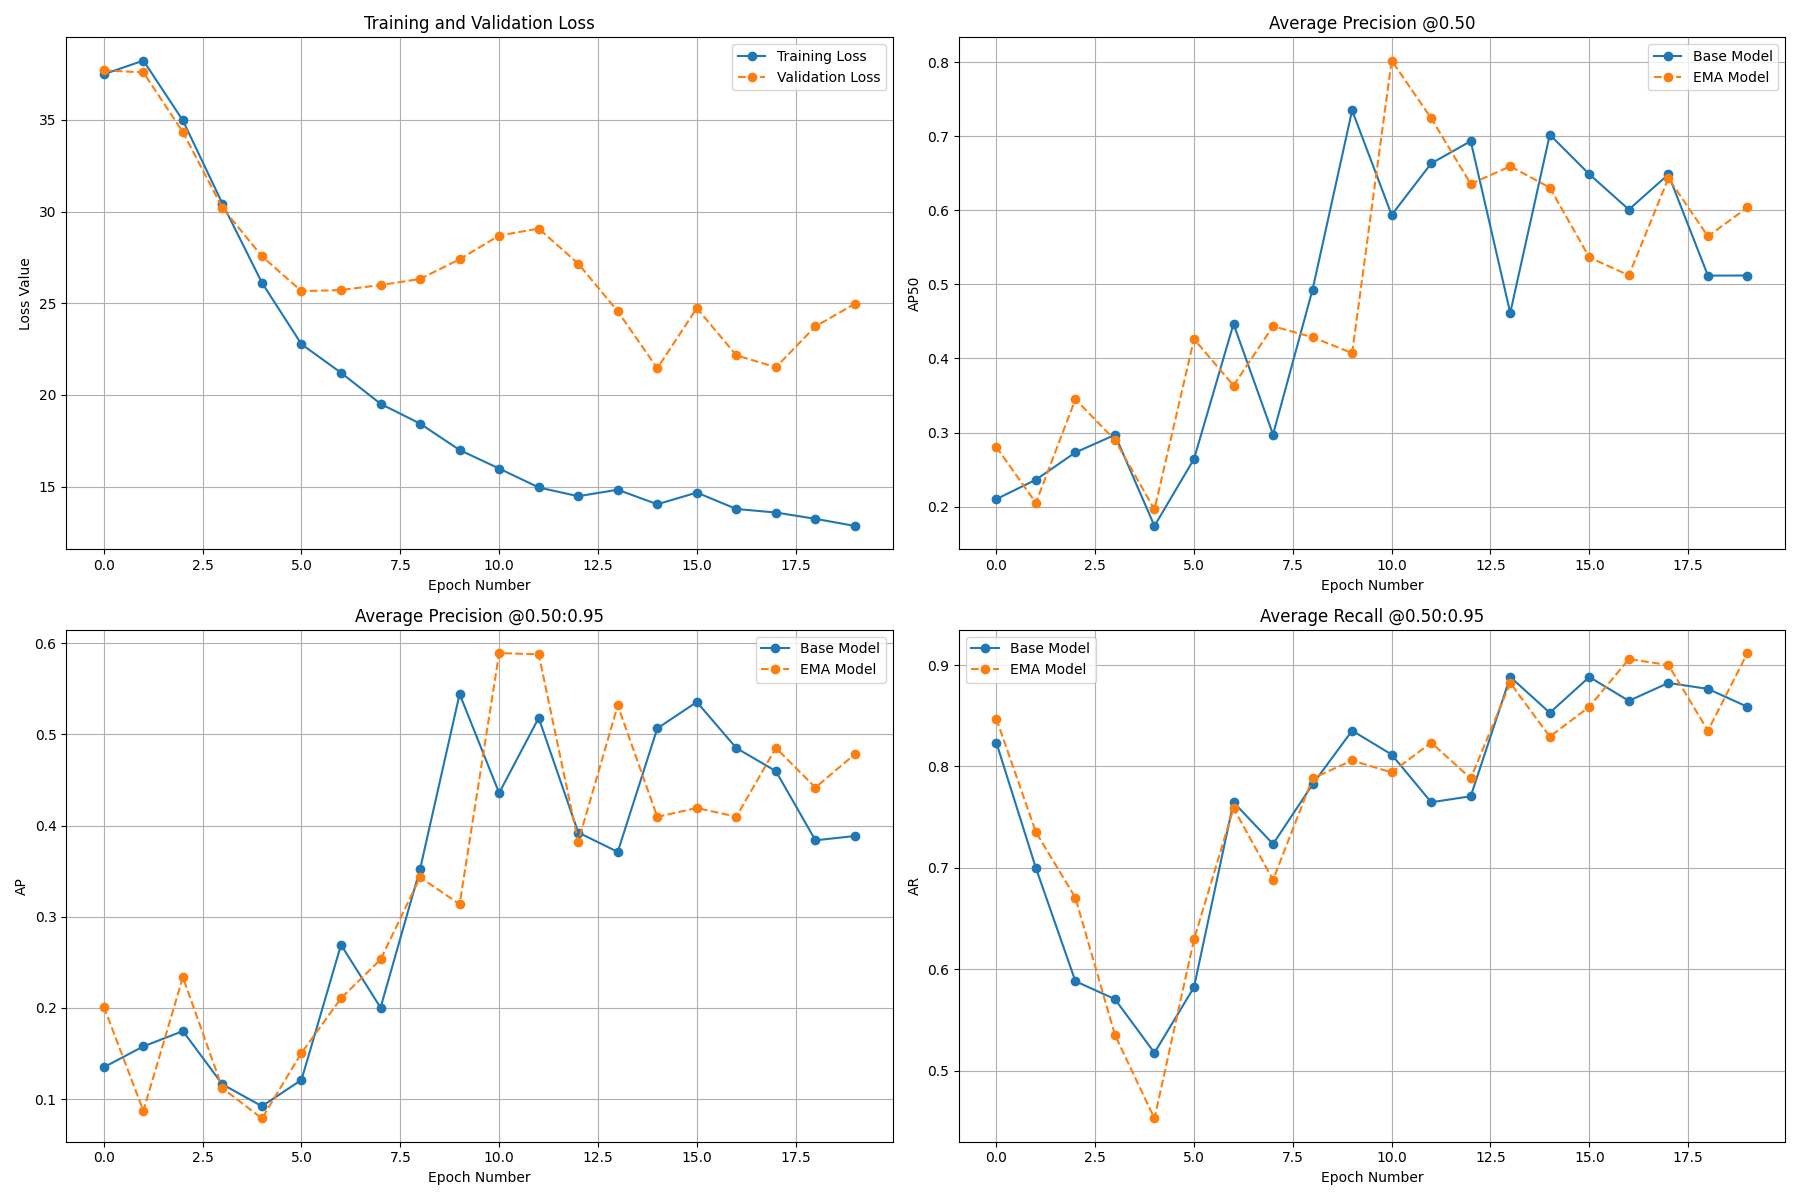

In [6]:
from PIL import Image

Image.open("/content/output/metrics_plot.png")

The trained model is checkpoint_best_total.pth.

In [7]:
!ls -la /content/output

total 2478492
drwxr-xr-x 3 root root      4096 Mar 27 22:49 .
drwxr-xr-x 1 root root      4096 Mar 27 22:38 ..
-rw-r--r-- 1 root root 534398511 Mar 27 22:44 checkpoint0009.pth
-rw-r--r-- 1 root root 534398511 Mar 27 22:49 checkpoint0019.pth
-rw-r--r-- 1 root root 399873726 Mar 27 22:44 checkpoint_best_ema.pth
-rw-r--r-- 1 root root 401162890 Mar 27 22:44 checkpoint_best_regular.pth
-rw------- 1 root root 133248663 Mar 27 22:49 checkpoint_best_total.pth
-rw-r--r-- 1 root root 534387619 Mar 27 22:49 checkpoint.pth
drwxr-xr-x 2 root root      4096 Mar 27 22:39 eval
-rw-r--r-- 1 root root      8752 Mar 27 22:49 events.out.tfevents.1774651132.b9bd06d3e248.19622.0
-rw-r--r-- 1 root root    223903 Mar 27 22:49 log.txt
-rw-r--r-- 1 root root    220032 Mar 27 22:49 metrics_plot.png
-rw-r--r-- 1 root root       809 Mar 27 22:49 results.json


### Install RF-DETR to CoreML

In [8]:
!git clone https://github.com/landchenxuan/rf-detr-to-coreml.git
%cd rf-detr-to-coreml
!pip install -q -e .

Cloning into 'rf-detr-to-coreml'...
remote: Enumerating objects: 99, done.
remote: Counting objects: 100% (99/99), done.
remote: Compressing objects: 100% (73/73), done.
remote: Total 99 (delta 38), reused 87 (delta 26), pack-reused 0 (from 0)
Receiving objects: 100% (99/99), 1.71 MiB | 5.52 MiB/s, done.
Resolving deltas: 100% (38/38), done.
/content/rf-detr-to-coreml
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.3/2.3 MB 43.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.1/73.1 kB 8.8 MB/s eta 0:00:00
  Building editable for rfdetr-coreml (pyproject.toml) ... done


Move the best model to the current folder and export to a Core ML model.

In [9]:
!mv /content/output/checkpoint_best_total.pth .

In [10]:
!rfdetr-coreml --model seg-nano --weights checkpoint_best_total.pth

scikit-learn version 1.6.1 is not supported. Minimum required version: 0.17. Maximum required version: 1.5.1. Disabling scikit-learn conversion API.
XGBoost version 3.2.0 has not been tested with coremltools. You may run into unexpected errors. XGBoost 1.4.2 is the most recent version that has been tested.
2026-03-27 23:03:28.227204: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1774652608.289350   27584 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1774652608.303122   27584 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1774652608.358722   27584 computation_placer.cc:177] computation placer already registered. Please check linkage and 

In [11]:
!ls -la output

total 12
drwxr-xr-x 3 root root 4096 Mar 27 23:04 .
drwxr-xr-x 7 root root 4096 Mar 27 23:04 ..
drwxr-xr-x 3 root root 4096 Mar 27 23:04 rf-detr-seg-nano-checkpoint_best_total-fp32.mlpackage


In [12]:
%cd output

/content/rf-detr-to-coreml/output


Zip the Core ML model and download it from the File browser at the left hand. You can auto label images using the Core ML model on RectLabel.

In [13]:
!zip -r seg-nano.zip rf-detr-seg-nano-checkpoint_best_total-fp32.mlpackage

  adding: rf-detr-seg-nano-checkpoint_best_total-fp32.mlpackage/ (stored 0%)
  adding: rf-detr-seg-nano-checkpoint_best_total-fp32.mlpackage/Manifest.json (deflated 59%)
  adding: rf-detr-seg-nano-checkpoint_best_total-fp32.mlpackage/Data/ (stored 0%)
  adding: rf-detr-seg-nano-checkpoint_best_total-fp32.mlpackage/Data/com.apple.CoreML/ (stored 0%)
  adding: rf-detr-seg-nano-checkpoint_best_total-fp32.mlpackage/Data/com.apple.CoreML/model.mlmodel (deflated 89%)
  adding: rf-detr-seg-nano-checkpoint_best_total-fp32.mlpackage/Data/com.apple.CoreML/weights/ (stored 0%)
  adding: rf-detr-seg-nano-checkpoint_best_total-fp32.mlpackage/Data/com.apple.CoreML/weights/weight.bin (deflated 7%)
